In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.model_selection import cross_val_score

from sklearn.metrics import precision_recall_curve, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv('../Data/input/creditcard.csv') 

X = df.drop(columns=["Class"])
y = df["Class"]

# Divisão teste e treino
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [3]:
# 3. Normalização com RobustScaler  (deixar os valores em escalas comparáveis)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test_scaled = scaler.transform(X_test[["Time", "Amount"]])


# 4. SMOTE para balanceamento (aumenta dados da classe minoritária, fraudes)
#smote = SMOTE(sampling_strategy='minority', random_state=42)
#X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)



In [4]:
rf_model = RandomForestClassifier(
    n_estimators=100, #número de árvores na floresta
    random_state=42, 
    max_depth=None, #profundidade máxima de cada árvore, none = crescem livremente
    min_samples_split= 5
    )   


In [5]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(min_samples_split=5, random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

# ele acerta 94% das vezes que a transação é fraude (poucos alarmes falsos)
# das fraudes que existem ele acertou 82%
# algumas fraudes passaram como se fossem legítimas


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [14]:
y_pred_train = rf_model.predict(X_train)

print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      0.96      0.98       394

    accuracy                           1.00    227845
   macro avg       1.00      0.98      0.99    227845
weighted avg       1.00      1.00      1.00    227845



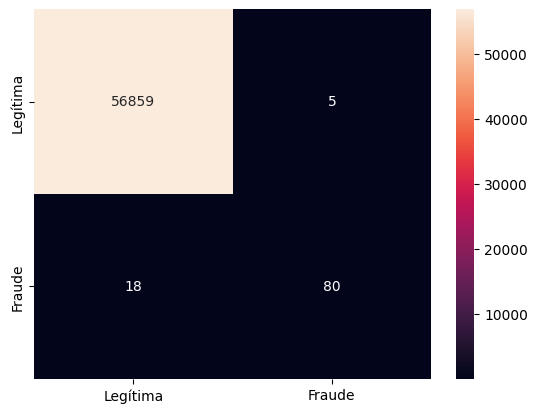

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Legítima','Fraude'],
            yticklabels=['Legítima','Fraude'])
plt.show()

# 56859: Transações legítimas corretamente classificadas como legítimas
# 5: Transações legítimas que o modelo acusou como fraude
# 18: fraudes foram classificadas como legítimas.
# 80: fraudes reais que foram detectadas

### Cross Validation

In [ ]:
rf_model_crossv = RandomForestClassifier(
    n_estimators=100, #número de árvores na floresta
    random_state=42, 
    max_depth=None, #profundidade máxima de cada árvore, none = crescem livremente
    min_samples_split= 5
    )   

cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f'Cross-Validation F1 scores: {cv_scores}')
print(f'Average F1 score: {cv_scores.mean()}')

# cv=5: five fold cross validation
# f1 score: métrica que combina precisão e recall em um único valor

#Treina a floresta várias vezes em diferentes subconjuntos do treino para obter uma medida mais confiavel do desempenho do modelo

Cross-Validation F1 scores: [0.2        0.12121212 0.14678899 0.15686275 0.08928571]
Average F1 score: 0.14282991428431255


In [9]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(min_samples_split=5, random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))


# ele acerta 94% das vezes que a transação é fraude (poucos alarmes falsos)
# das fraudes que existem ele acertou 82%
# algumas fraudes passaram como se fossem legítimas

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



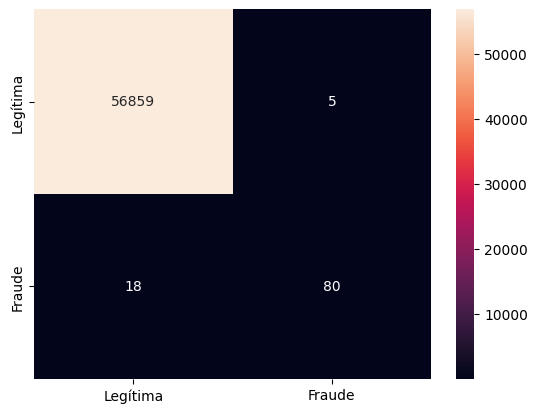

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Legítima','Fraude'],
            yticklabels=['Legítima','Fraude'])
plt.show()